# Sesión 2 – Algoritmos Genéticos
## Cruce, generaciones y convergencia

En esta sesión ampliamos el algoritmo genético introduciendo:
- Cruce (recombinación)
- Varias generaciones
- Análisis de la convergencia


## 1. Recordatorio rápido

En la sesión anterior vimos:
- Población inicial
- Función de fitness
- Selección por ruleta
- Mutación

Ahora vamos a **cerrar el ciclo completo** de un algoritmo genético.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


## 2. Problema de optimización

Seguimos maximizando:

$$f(x) = -(x - 3)^2 + 10$$


In [2]:
def fitness(x):
    return -(x - 3)**2 + 10


## 3. Inicialización de la población


In [3]:
np.random.seed(1)
N = 20
poblacion = np.random.uniform(-5, 10, size=N)


## 4. Cruce (recombinación)

El cruce combina información de dos padres para generar descendencia.

Usaremos **cruce aritmético**:
$$ hijo = \alpha p_1 + (1-\alpha) p_2 $$


In [4]:
def cruce(p1, p2, alpha=0.5):
    return alpha * p1 + (1 - alpha) * p2


## 5. Bucle evolutivo completo


In [5]:
generaciones = 30
tasa_mutacion = 0.1

mejor_fitness = []
fitness_medio = []

for g in range(generaciones):
    # Evaluación
    fitness_vals = fitness(poblacion)
    mejor_fitness.append(fitness_vals.max())
    fitness_medio.append(fitness_vals.mean())

    # Selección por ruleta
    fitness_shifted = fitness_vals - fitness_vals.min() + 1e-6
    prob = fitness_shifted / fitness_shifted.sum()
    padres = np.random.choice(poblacion, size=N, p=prob)

    # Cruce
    hijos = []
    for i in range(0, N, 2):
        p1, p2 = padres[i], padres[(i+1) % N]
        hijos.append(cruce(p1, p2))
        hijos.append(cruce(p2, p1))
    hijos = np.array(hijos[:N])

    # Mutación
    mutaciones = np.random.normal(0, tasa_mutacion, size=N)
    poblacion = hijos + mutaciones


## 6. Análisis de la convergencia


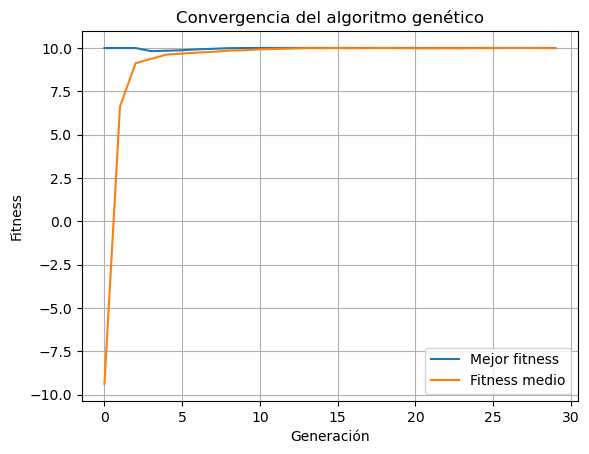

In [6]:
plt.plot(mejor_fitness, label='Mejor fitness')
plt.plot(fitness_medio, label='Fitness medio')
plt.xlabel('Generación')
plt.ylabel('Fitness')
plt.title('Convergencia del algoritmo genético')
plt.legend()
plt.grid(True)
plt.show()


## 7. Conclusiones

- El cruce acelera la convergencia.
- La mutación evita estancamiento.
- El fitness medio y el mejor fitness permiten diagnosticar el algoritmo.
